In [2]:
# Importuri de bază
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
 

# Citirea datelor
train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")

train.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


,missing_fraction,missing_pct
PoolQC,0.9952,99.52
MiscFeature,0.9630,96.30
Alley,0.9377,93.77
Fence,0.8075,80.75
MasVnrType,0.5973,59.73
FireplaceQu,0.4726,47.26
LotFrontage,0.1774,17.74
GarageQual,0.0555,5.55
GarageFinish,0.0555,5.55
GarageType,0.0555,5.55


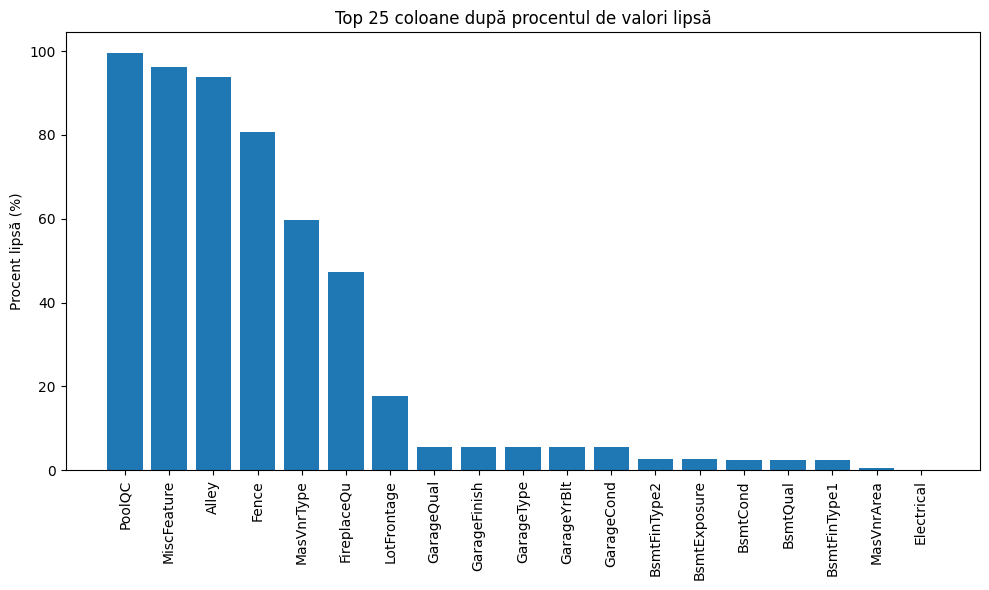

In [3]:
# Lipsuri: tabel (top) + bar chart

# %%
missing_frac = train.isnull().mean().sort_values(ascending=False)
missing_top  = (missing_frac[missing_frac > 0]
                .to_frame("missing_fraction")
                .assign(missing_pct=lambda df: 100*df["missing_fraction"])
                .round({"missing_fraction": 4, "missing_pct": 2}))
display(missing_top.head(25))

plt.figure(figsize=(10,6))
topk = 25
top_cols = missing_top.head(topk).index.tolist()
plt.bar(range(len(top_cols)), missing_top.loc[top_cols, "missing_pct"].values)
plt.xticks(range(len(top_cols)), top_cols, rotation=90)
plt.ylabel("Procent lipsă (%)")
plt.title(f"Top {topk} coloane după procentul de valori lipsă")
plt.tight_layout()
plt.show()

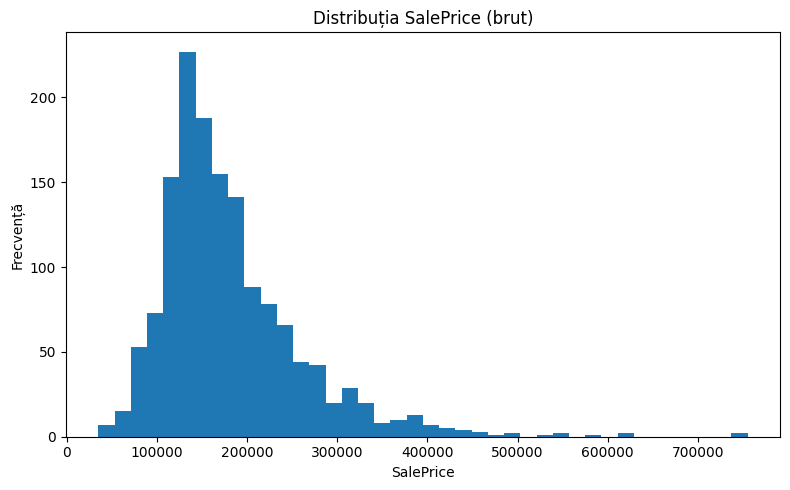

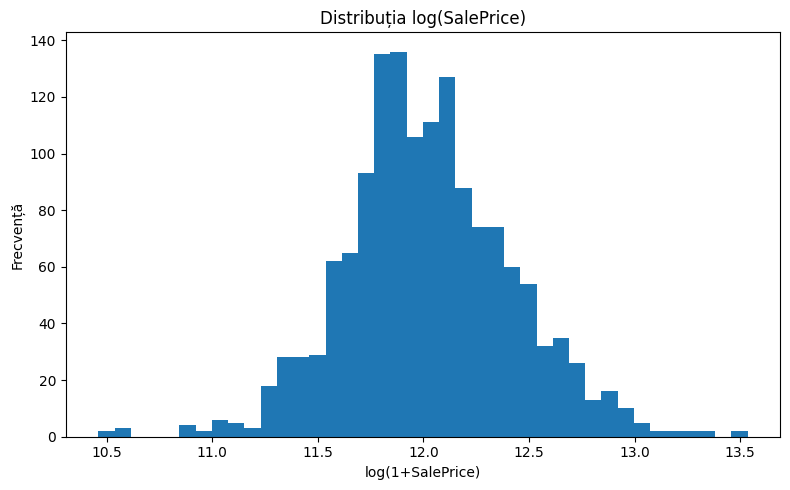

In [5]:
# Distribuții: SalePrice (brut) + log


sp = train["SalePrice"].dropna()

plt.figure(figsize=(8,5))
plt.hist(sp, bins=40)
plt.xlabel("SalePrice")
plt.ylabel("Frecvență")
plt.title("Distribuția SalePrice (brut)")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8,5))
plt.hist(np.log1p(sp), bins=40)
plt.xlabel("log(1+SalePrice)")
plt.ylabel("Frecvență")
plt.title("Distribuția log(SalePrice)")
plt.tight_layout()
plt.show()

In [6]:
# Corelații cu ținta: listă top 15

# %%
num_train = train.select_dtypes(include=[np.number])
corr = num_train.corr()
top_corr = corr["SalePrice"].drop("SalePrice").sort_values(ascending=False).head(15)
display(top_corr.to_frame("corr_with_SalePrice"))

,corr_with_SalePrice
OverallQual,0.790982
GrLivArea,0.708624
GarageCars,0.640409
GarageArea,0.623431
TotalBsmtSF,0.613581
1stFlrSF,0.605852
FullBath,0.560664
TotRmsAbvGrd,0.533723
YearBuilt,0.522897
YearRemodAdd,0.507101


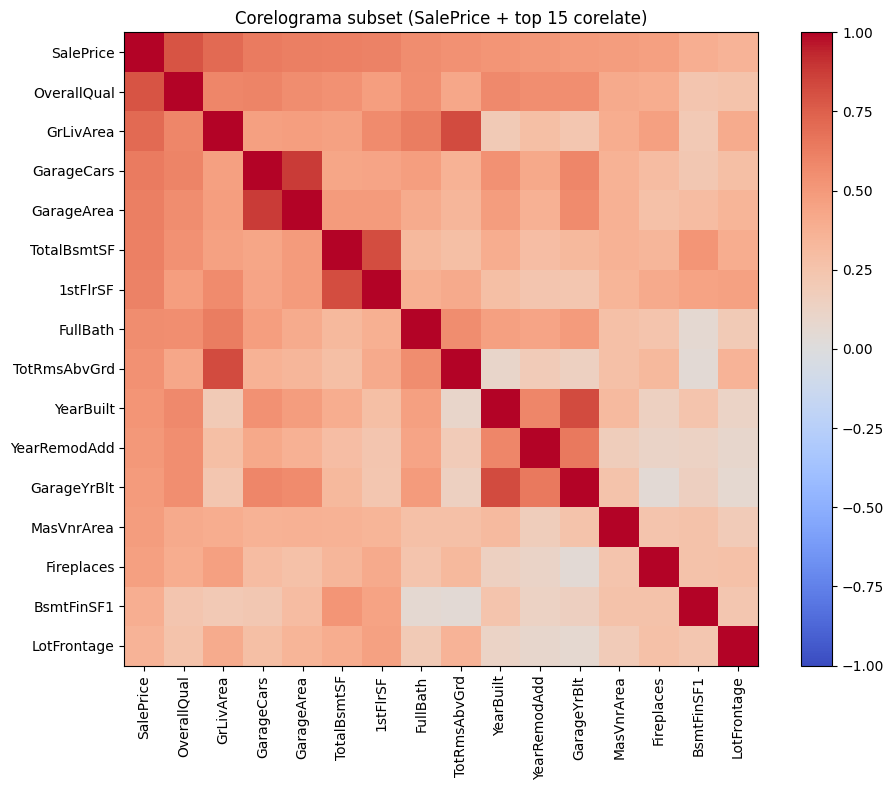

In [7]:
# Corelogramă pe subsetul (SalePrice + top 15 corelate)

# %%
subset_cols = ["SalePrice"] + top_corr.index.tolist()
corr_sub = corr.loc[subset_cols, subset_cols]

plt.figure(figsize=(10,8))
plt.imshow(corr_sub, cmap="coolwarm", vmin=-1, vmax=1)
plt.colorbar()
plt.title("Corelograma subset (SalePrice + top 15 corelate)")
plt.xticks(range(len(subset_cols)), subset_cols, rotation=90)
plt.yticks(range(len(subset_cols)), subset_cols)
plt.tight_layout()
plt.show()
